# Variational Autoencoders (VAE)

## Introduction

**Variational Autoencoders (VAEs)** are a powerful class of generative models that combine deep learning with probabilistic inference. Unlike regular autoencoders that learn an arbitrary encoding, VAEs learn a **structured probabilistic latent space** that enables:

1. **Smooth interpolation** between data points
2. **Random sampling** to generate new data
3. **Meaningful latent dimensions** that capture data variation

In this notebook, we'll build deep intuitions about VAEs by:
- Understanding the limitations of regular autoencoders
- Deriving the VAE objective from first principles
- Implementing the reparameterization trick
- Visualizing and exploring the learned latent space
- Generating new samples from the model

## Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from aiml_notebooks import (
    get_device, set_seed, count_parameters,
    VAELoss, visualize_reconstructions,
    extract_latent_representations, visualize_latent_space,
    interpolate_latents, spherical_interpolation,
)

%load_ext autoreload
%autoreload 2

Set random seed for reproducibility and configure device.

In [2]:
set_seed(42)
device = get_device()

Using MPS (Metal Performance Shaders) for GPU acceleration


## Data Preparation

We'll use **MNIST** handwritten digits for this notebook. MNIST is perfect for VAEs because:
- Simple grayscale images (28x28)
- Clear semantic structure (10 digit classes)
- Fast training for experimentation

In [3]:
# Transform - just convert to tensor (images already in [0, 1])
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset):,}")
print(f"Test samples: {len(test_dataset):,}")
print(f"Batches per epoch: {len(train_loader)}")
print(f"Image value range: [0, 1] (unnormalized)")

Training samples: 60,000
Test samples: 10,000
Batches per epoch: 469
Image value range: [0, 1] (unnormalized)


Let's visualize some samples from the dataset to understand what we're working with.

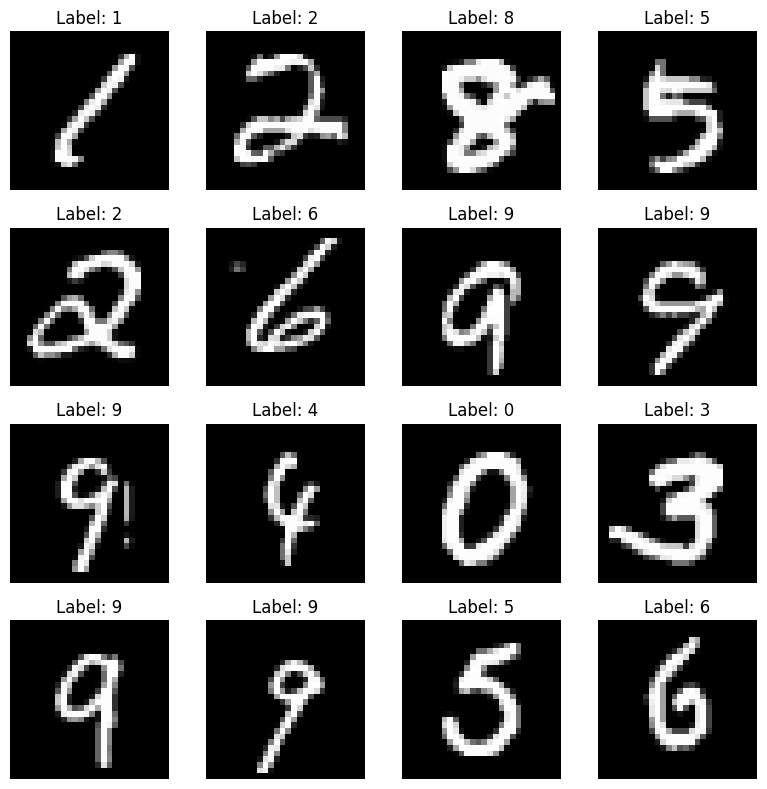

In [4]:
# Get a batch of training data
sample_batch, sample_labels = next(iter(train_loader))

# Plot first 16 images (no denormalization needed - already in [0, 1])
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_batch[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"Label: {sample_labels[i].item()}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## The Problem with Regular Autoencoders

Before diving into VAEs, let's understand what's wrong with regular autoencoders for **generation**.

### Regular Autoencoder Limitations

A standard autoencoder learns an encoder $E$ and decoder $D$ such that $D(E(x)) \approx x$. However:

1. **Discontinuous latent space**: Latent codes can be scattered anywhere
2. **No generation guarantee**: Random samples from latent space may decode to garbage
3. **Poor interpolation**: Intermediate points between valid codes may be invalid

The core issue: **regular autoencoders only learn to encode/decode training data, not to structure the latent space**.

## The VAE Solution: Probabilistic Latent Space

VAEs solve this by enforcing a **structured probabilistic latent space**.

### Key Insight

Instead of encoding an input $x$ to a single point $z$, VAE encodes to a **distribution** $q(z|x)$. We then:
1. Sample $z \sim q(z|x)$
2. Decode $z$ back to reconstruction

### The VAE Objective

VAEs maximize the **Evidence Lower Bound (ELBO)**:

$$\mathcal{L}_{\text{VAE}} = \underbrace{\mathbb{E}_{z \sim q(z|x)}[\log p(x|z)]}_\text{Reconstruction} - \underbrace{D_{\text{KL}}(q(z|x) \| p(z))}_\text{Regularization}$$

Where:
- $q(z|x)$ is the **encoder distribution** (typically Gaussian)
- $p(z)$ is the **prior** (standard normal $\mathcal{N}(0, I)$)
- $p(x|z)$ is the **decoder distribution**

### What Does Each Term Do?

1. **Reconstruction term**: Forces decoder to reconstruct inputs (like regular AE)
2. **KL divergence term**: Forces $q(z|x)$ to match prior $p(z)$, ensuring:
   - Latent codes stay near origin
   - Different encodings overlap (enabling interpolation)
   - Random samples from $p(z)$ decode to valid outputs

## The Reparameterization Trick

### The Challenge

We want to train with gradient descent, but **sampling is not differentiable**:

$$z \sim \mathcal{N}(\mu, \sigma^2) \quad \text{← Can't backprop through sampling!}$$

### The Solution

**Reparameterization trick**: Express $z$ as a deterministic function of $\mu$, $\sigma$, and noise $\epsilon$:

$$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

Now:
- $\epsilon$ is sampled (fixed, no gradients)
- $z$ is a differentiable function of $\mu$ and $\sigma$
- Gradients flow through $\mu$ and $\sigma$ to the encoder!

This is the **key trick** that makes VAEs trainable with backpropagation.

## Building the VAE: Encoder

The encoder maps input $x$ to latent distribution parameters $\mu$ and $\log\sigma^2$.

### Why predict $\log\sigma^2$ instead of $\sigma$?

- $\sigma^2$ must be positive (variance)
- Predicting $\log\sigma^2$ allows network to output any real number
- We can always get $\sigma = \exp(0.5 \cdot \log\sigma^2)$

In [5]:
class VAEEncoder(nn.Module):
    """Encoder that maps input to latent distribution parameters."""
    
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)  # Mean
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)  # Log variance
    
    def forward(self, x):
        # Flatten image: (batch, 1, 28, 28) -> (batch, 784)
        x = x.view(x.size(0), -1)
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

Test the encoder to verify output shapes.

In [6]:
# Create encoder
encoder = VAEEncoder(latent_dim=20).to(device)
print(f"Encoder parameters: {count_parameters(encoder):,}")

# Test with sample batch
test_input = sample_batch[:4].to(device)
mu, logvar = encoder(test_input)

print(f"\nInput shape: {test_input.shape}")
print(f"μ shape: {mu.shape}")
print(f"log σ² shape: {logvar.shape}")
print(f"\nSample μ: {mu[0, :5].detach().cpu().numpy()}")
print(f"Sample log σ²: {logvar[0, :5].detach().cpu().numpy()}")

Encoder parameters: 330,040

Input shape: torch.Size([4, 1, 28, 28])
μ shape: torch.Size([4, 20])
log σ² shape: torch.Size([4, 20])

Sample μ: [-0.04495437  0.01145621  0.07735318  0.08188089  0.01308224]
Sample log σ²: [0.0186447  0.06333534 0.06455015 0.01081558 0.07086535]


## Sampling with Reparameterization

Now we implement the reparameterization trick to sample $z$ from the latent distribution.

In [7]:
def reparameterize(mu, logvar):
    """
    Reparameterization trick: z = μ + σ * ε, where ε ~ N(0, I)
    
    Args:
        mu: Mean of latent distribution (batch_size, latent_dim)
        logvar: Log variance of latent distribution (batch_size, latent_dim)
    
    Returns:
        z: Sampled latent vector (batch_size, latent_dim)
    """
    std = torch.exp(0.5 * logvar)  # Convert log variance to std deviation
    eps = torch.randn_like(std)  # Sample ε ~ N(0, I)
    z = mu + std * eps  # Reparameterization
    return z

Visualize the reparameterization trick in action.

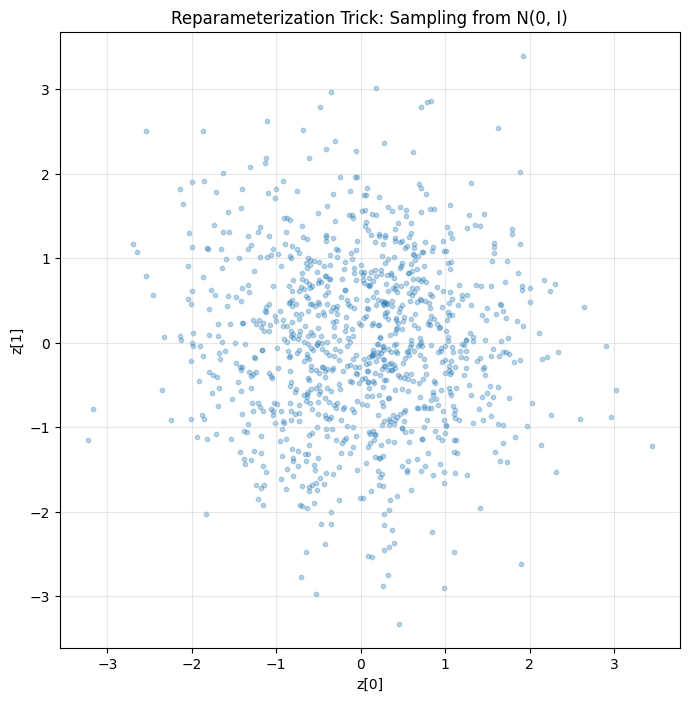

Sample mean: [-0.00174612  0.0008661 ]
Sample std: [0.99657464 1.019024  ]


In [8]:
# Sample multiple latent codes from same distribution
num_samples = 1000
mu_example = torch.zeros(num_samples, 2).to(device)
logvar_example = torch.zeros(num_samples, 2).to(device)

# Sample using reparameterization
z_samples = reparameterize(mu_example, logvar_example)

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(z_samples[:, 0].cpu(), z_samples[:, 1].cpu(), alpha=0.3, s=10)
plt.xlabel('z[0]')
plt.ylabel('z[1]')
plt.title('Reparameterization Trick: Sampling from N(0, I)')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

print(f"Sample mean: {z_samples.mean(dim=0).cpu().numpy()}")
print(f"Sample std: {z_samples.std(dim=0).cpu().numpy()}")

Notice how the samples follow a standard normal distribution, as expected from $\mathcal{N}(0, I)$.

## Building the VAE: Decoder

The decoder maps latent code $z$ back to reconstructed image $\hat{x}$.

**Key design choice**: We use **sigmoid activation** to output pixel probabilities in $[0, 1]$. This works perfectly with BCE loss, treating each pixel as a Bernoulli random variable.

In [9]:
class VAEDecoder(nn.Module):
    """Decoder that maps latent code to reconstructed image."""
    
    def __init__(self, latent_dim=20, hidden_dim=400, output_dim=784):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, z):
        h = F.relu(self.fc1(z))
        x_recon = torch.sigmoid(self.fc2(h))  # Sigmoid for [0, 1] pixel values
        # Reshape to image: (batch, 784) -> (batch, 1, 28, 28)
        x_recon = x_recon.view(x_recon.size(0), 1, 28, 28)
        return x_recon

Test the decoder with random latent codes.

In [10]:
# Create decoder
decoder = VAEDecoder(latent_dim=20).to(device)
print(f"Decoder parameters: {count_parameters(decoder):,}")

# Test with random latent codes
test_z = torch.randn(4, 20).to(device)
test_recon = decoder(test_z)

print(f"\nLatent code shape: {test_z.shape}")
print(f"Reconstruction shape: {test_recon.shape}")

Decoder parameters: 322,784

Latent code shape: torch.Size([4, 20])
Reconstruction shape: torch.Size([4, 1, 28, 28])


## Complete VAE Model

Now we combine encoder, reparameterization, and decoder into a complete VAE.

In [11]:
class VAE(nn.Module):
    """Complete Variational Autoencoder."""
    
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        self.encoder = VAEEncoder(input_dim, hidden_dim, latent_dim)
        self.decoder = VAEDecoder(latent_dim, hidden_dim, input_dim)
        self.latent_dim = latent_dim
    
    def encode(self, x):
        """Encode input to latent distribution parameters."""
        return self.encoder(x)
    
    def decode(self, z):
        """Decode latent code to reconstruction."""
        return self.decoder(z)
    
    def forward(self, x):
        """Full forward pass: encode, sample, decode."""
        # Encode
        mu, logvar = self.encode(x)
        
        # Reparameterization
        z = reparameterize(mu, logvar)
        
        # Decode
        x_recon = self.decode(z)
        
        return x_recon, mu, logvar
    
    def sample(self, num_samples, device):
        """Generate new samples from prior p(z) = N(0, I)."""
        z = torch.randn(num_samples, self.latent_dim).to(device)
        samples = self.decode(z)
        return samples

Create the VAE model and verify its structure.

In [12]:
# Create VAE
latent_dim = 20
vae = VAE(input_dim=784, hidden_dim=400, latent_dim=latent_dim).to(device)

print(f"Total parameters: {count_parameters(vae):,}")
print(f"Encoder parameters: {count_parameters(vae.encoder):,}")
print(f"Decoder parameters: {count_parameters(vae.decoder):,}")

# Test forward pass
test_input = sample_batch[:4].to(device)
test_recon, test_mu, test_logvar = vae(test_input)

print(f"\nInput shape: {test_input.shape}")
print(f"Reconstruction shape: {test_recon.shape}")
print(f"μ shape: {test_mu.shape}")
print(f"log σ² shape: {test_logvar.shape}")

Total parameters: 652,824
Encoder parameters: 330,040
Decoder parameters: 322,784

Input shape: torch.Size([4, 1, 28, 28])
Reconstruction shape: torch.Size([4, 1, 28, 28])
μ shape: torch.Size([4, 20])
log σ² shape: torch.Size([4, 20])


## VAE Loss Function

The VAE loss combines reconstruction loss and KL divergence:

$$\mathcal{L} = \text{Reconstruction Loss} + \beta \cdot D_{\text{KL}}$$

### Reconstruction Loss

For **binary/grayscale images like MNIST**, we use **Binary Cross-Entropy (BCE)**:
- Treats each pixel as a Bernoulli random variable
- Decoder outputs probabilities via sigmoid
- Much sharper reconstructions than MSE
- Proper black backgrounds (no averaging to gray)

**Why BCE > MSE for MNIST:**
- MSE encourages "average" outputs → grayish backgrounds
- BCE encourages discrete 0/1 decisions → true black/white
- MNIST is essentially binary (black vs white), not continuous

### KL Divergence
For diagonal Gaussians, KL has closed form:

$$D_{\text{KL}}(q(z|x) \| p(z)) = -\frac{1}{2} \sum_{j=1}^{d} (1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2)$$

### Beta Parameter
$\beta$ controls the tradeoff:
- $\beta < 1$: prioritize reconstruction (sharper images)
- $\beta = 1$: standard VAE
- $\beta > 1$: prioritize regularization (better disentanglement, sometimes called **β-VAE**)

We'll use the shared `VAELoss` from our library which handles both terms.

In [13]:
# Create loss function (beta=1 for standard VAE, BCE for binary images)
criterion = VAELoss(reconstruction_loss='bce', beta=1.0)

# Test loss computation
test_loss, test_recon_loss, test_kl_loss = criterion(
    test_recon, test_input, test_mu, test_logvar
)

print(f"Total loss: {test_loss.item():.4f}")
print(f"Reconstruction loss (BCE): {test_recon_loss.item():.4f}")
print(f"KL divergence: {test_kl_loss.item():.4f}")

Total loss: 547.8110
Reconstruction loss (BCE): 547.6854
KL divergence: 0.1257


## Training the VAE

Now we'll train the VAE on MNIST. We'll track both reconstruction and KL losses separately to monitor training.

In [14]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    for batch_idx, (data, _) in enumerate(tqdm(dataloader, desc='Training')):
        data = data.to(device)
        
        # Forward pass
        recon, mu, logvar = model(data)
        loss, recon_loss, kl_loss = criterion(recon, data, mu, logvar)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate losses
        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_kl_loss += kl_loss.item()
    
    n_batches = len(dataloader)
    return total_loss / n_batches, total_recon_loss / n_batches, total_kl_loss / n_batches


def evaluate(model, dataloader, criterion, device):
    """Evaluate on validation/test set."""
    model.eval()
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    with torch.no_grad():
        for data, _ in dataloader:
            data = data.to(device)
            recon, mu, logvar = model(data)
            loss, recon_loss, kl_loss = criterion(recon, data, mu, logvar)
            
            total_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()
    
    n_batches = len(dataloader)
    return total_loss / n_batches, total_recon_loss / n_batches, total_kl_loss / n_batches

Train the VAE for several epochs.

In [15]:
# Training setup
num_epochs = 10
learning_rate = 1e-3

# Recreate model to start fresh
vae = VAE(input_dim=784, hidden_dim=400, latent_dim=latent_dim).to(device)
criterion = VAELoss(reconstruction_loss='mse', beta=1.0)
optimizer = torch.optim.Adam(vae.parameters(), lr=learning_rate)

# Training history
history = {
    'train_loss': [], 'train_recon': [], 'train_kl': [],
    'test_loss': [], 'test_recon': [], 'test_kl': []
}

print(f"Training VAE for {num_epochs} epochs...\n")

for epoch in range(num_epochs):
    # Train
    train_loss, train_recon, train_kl = train_epoch(
        vae, train_loader, criterion, optimizer, device
    )
    
    # Evaluate
    test_loss, test_recon, test_kl = evaluate(
        vae, test_loader, criterion, device
    )
    
    # Record history
    history['train_loss'].append(train_loss)
    history['train_recon'].append(train_recon)
    history['train_kl'].append(train_kl)
    history['test_loss'].append(test_loss)
    history['test_recon'].append(test_recon)
    history['test_kl'].append(test_kl)
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train - Loss: {train_loss:.4f}, Recon: {train_recon:.4f}, KL: {train_kl:.4f}")
    print(f"  Test  - Loss: {test_loss:.4f}, Recon: {test_recon:.4f}, KL: {test_kl:.4f}")

print("\nTraining complete!")

Training VAE for 10 epochs...



Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/10
  Train - Loss: 45.3464, Recon: 39.2838, KL: 6.0627
  Test  - Loss: 36.4964, Recon: 27.3614, KL: 9.1350


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/10
  Train - Loss: 35.0158, Recon: 24.8507, KL: 10.1652
  Test  - Loss: 33.5317, Recon: 22.9129, KL: 10.6188


...

Epoch 8/10
  Train - Loss: 31.0184, Recon: 18.7977, KL: 12.2208
  Test  - Loss: 30.7088, Recon: 18.2568, KL: 12.4519


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9/10
  Train - Loss: 30.8442, Recon: 18.5599, KL: 12.2843
  Test  - Loss: 30.6278, Recon: 17.8922, KL: 12.7355


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/10
  Train - Loss: 30.6852, Recon: 18.3766, KL: 12.3086
  Test  - Loss: 30.3765, Recon: 17.8100, KL: 12.5664

Training complete!


Visualize the training curves to understand how the model learned.

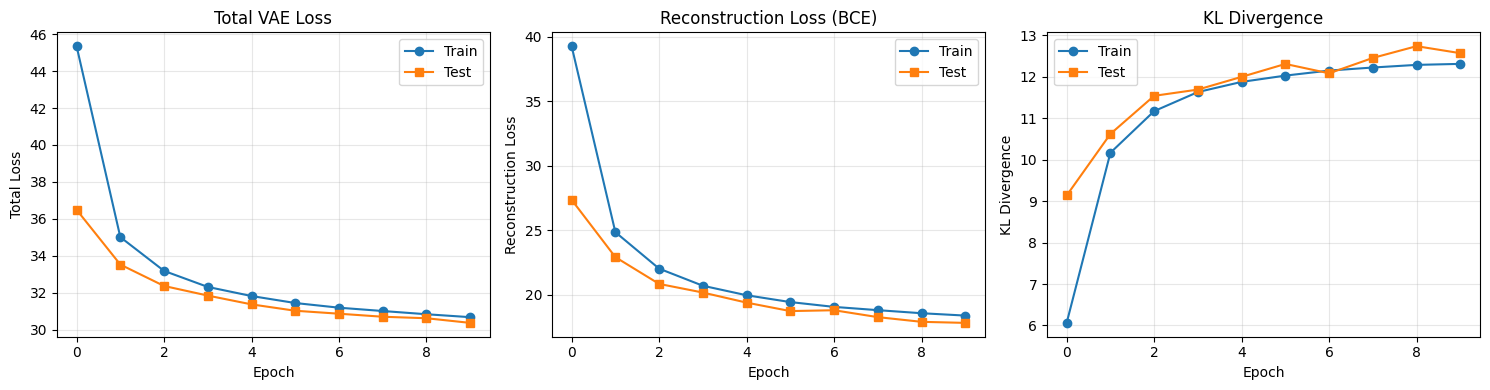

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Total loss
axes[0].plot(history['train_loss'], label='Train', marker='o')
axes[0].plot(history['test_loss'], label='Test', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Total VAE Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Reconstruction loss
axes[1].plot(history['train_recon'], label='Train', marker='o')
axes[1].plot(history['test_recon'], label='Test', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Reconstruction Loss (BCE)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# KL divergence
axes[2].plot(history['train_kl'], label='Train', marker='o')
axes[2].plot(history['test_kl'], label='Test', marker='s')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Key observations:**
- **Reconstruction loss** steadily decreases as the decoder improves
- **KL divergence** represents the "cost" of regularizing the latent space
- The sum of both gives the total VAE loss

## Evaluating Reconstructions

Let's see how well the VAE reconstructs test images.

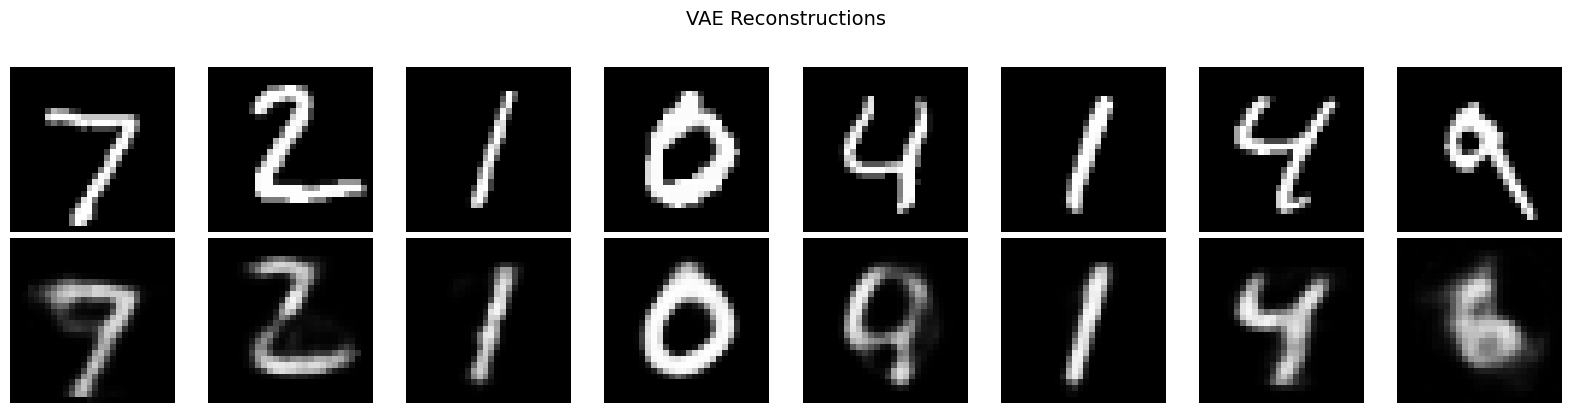

In [17]:
# Get test batch
test_batch, test_labels = next(iter(test_loader))
test_batch = test_batch.to(device)

# Reconstruct
vae.eval()
with torch.no_grad():
    recon_batch, mu, logvar = vae(test_batch)

# No denormalization needed - images already in [0, 1]
# Visualize
n_samples = 8
fig, axes = plt.subplots(2, n_samples, figsize=(16, 4))

for i in range(n_samples):
    # Original
    axes[0, i].imshow(test_batch[i].cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=12)
    
    # Reconstruction
    axes[1, i].imshow(recon_batch[i].cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('Reconstructed', fontsize=12)

plt.suptitle('VAE Reconstructions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Notice that reconstructions are sharper than MSE-based VAEs, but still slightly blurry. This is inherent to VAEs because:
1. **KL regularization** prevents overfitting to exact pixel values
2. **Probabilistic reconstruction** - the model must reconstruct from a **sampled** (noisy) latent code
3. **Structured latent space** - maintaining continuity trades off some reconstruction quality

BCE loss gives us **proper black backgrounds** and **sharper edges**, but perfect pixel-level reconstruction would sacrifice the smooth, structured latent space that makes VAEs powerful for generation and interpolation.

## Exploring the Latent Space

The real power of VAEs is the **structured latent space**. Let's visualize it!

### 2D Latent Space Visualization

For full visualization, we'll train a VAE with 2D latent space. This lets us see the complete latent distribution.

In [18]:
# Train a 2D VAE for visualization
print("Training 2D VAE for visualization...\n")
vae_2d = VAE(input_dim=784, hidden_dim=400, latent_dim=2).to(device)
criterion_2d = VAELoss(reconstruction_loss='mse', beta=1.0)
optimizer_2d = torch.optim.Adam(vae_2d.parameters(), lr=1e-3)

# Train for fewer epochs (just for visualization)
for epoch in range(10):
    train_loss, train_recon, train_kl = train_epoch(
        vae_2d, train_loader, criterion_2d, optimizer_2d, device
    )
    print(f"Epoch {epoch+1}/10 - Loss: {train_loss:.4f}")

print("\n2D VAE training complete!")

Training 2D VAE for visualization...



Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1/10 - Loss: 49.1414


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2/10 - Loss: 42.4249


...

Epoch 8/10 - Loss: 39.1144


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9/10 - Loss: 38.8993


Training:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/10 - Loss: 38.7104

2D VAE training complete!


Now let's visualize how the different digit classes are distributed in the 2D latent space.

Encoding test set:   0%|          | 0/79 [00:00<?, ?it/s]

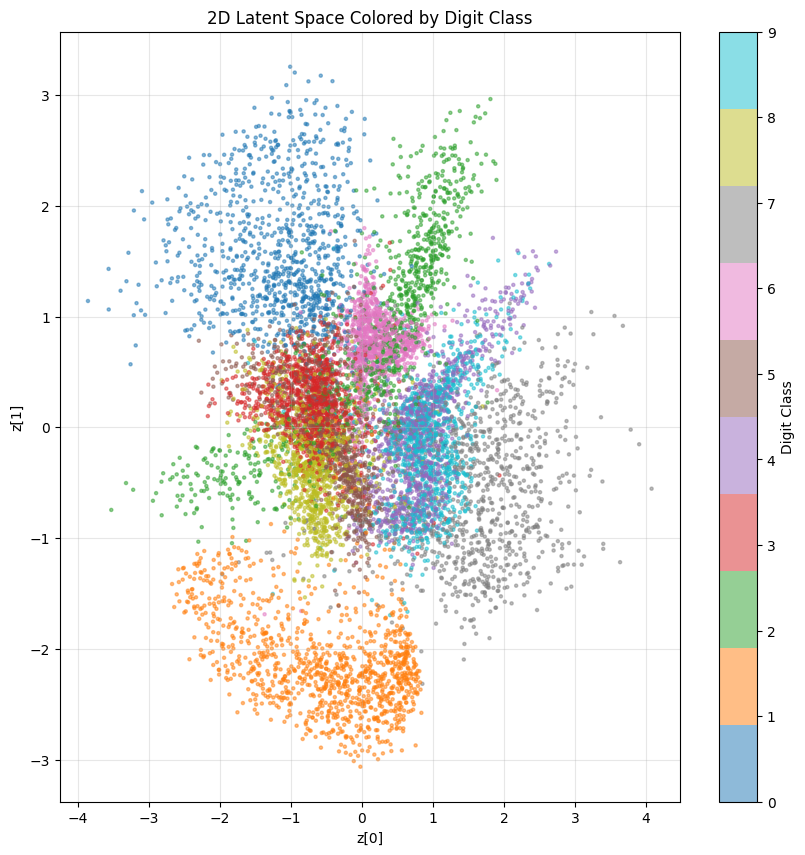

In [19]:
# Extract latent codes for test set
vae_2d.eval()
latent_codes = []
labels = []

with torch.no_grad():
    for data, label in tqdm(test_loader, desc='Encoding test set'):
        data = data.to(device)
        mu, _ = vae_2d.encode(data)
        latent_codes.append(mu.cpu())
        labels.append(label)

latent_codes = torch.cat(latent_codes, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

# Plot latent space
plt.figure(figsize=(10, 10))
scatter = plt.scatter(latent_codes[:, 0], latent_codes[:, 1], 
                     c=labels, cmap='tab10', alpha=0.5, s=5)
plt.colorbar(scatter, label='Digit Class')
plt.xlabel('z[0]')
plt.ylabel('z[1]')
plt.title('2D Latent Space Colored by Digit Class')
plt.grid(True, alpha=0.3)
plt.show()

**Key insight:** Different digit classes cluster in different regions of latent space, but with **smooth transitions** between clusters. This structure is what enables generation and interpolation!

### Latent Space Manifold

We can visualize the **decoder manifold** by decoding a grid of latent points.

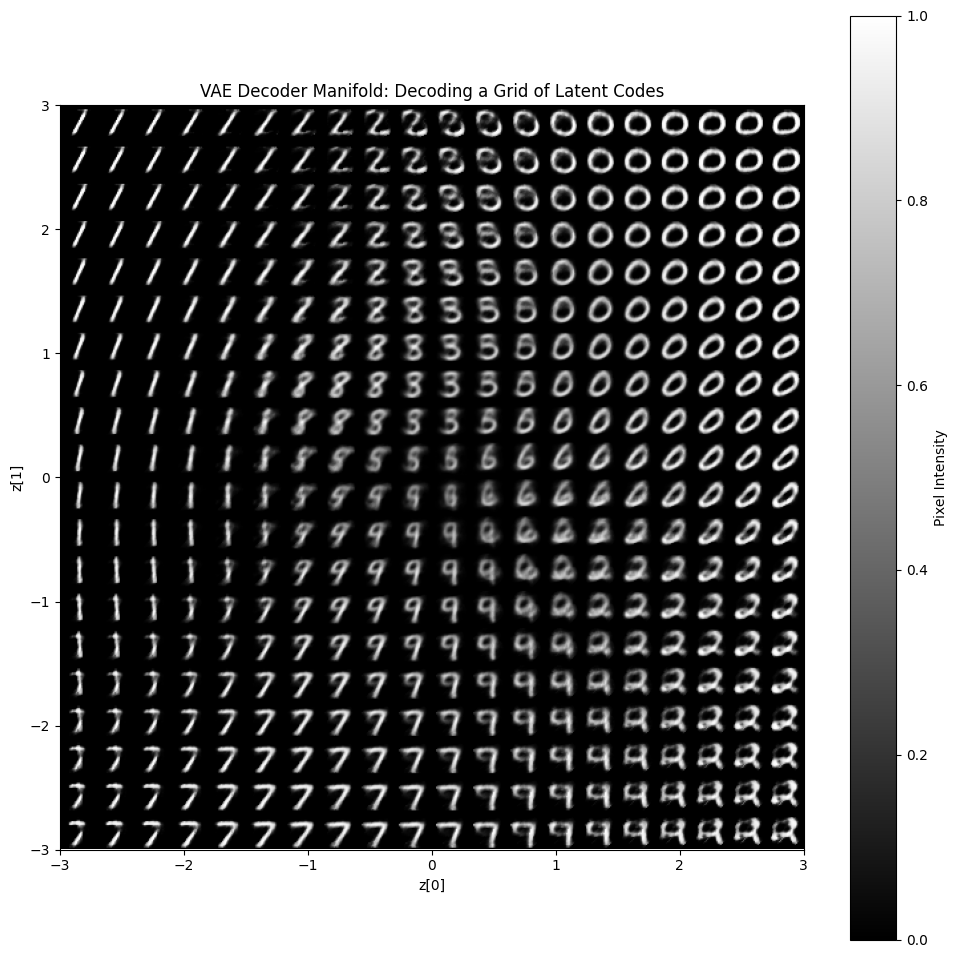

In [20]:
# Create a grid of latent codes
n = 20  # Grid size
z_range = 3  # Range of z values
z0_vals = np.linspace(-z_range, z_range, n)
z1_vals = np.linspace(-z_range, z_range, n)

# Decode each grid point
vae_2d.eval()
canvas = np.zeros((28 * n, 28 * n))

with torch.no_grad():
    for i, z0 in enumerate(z0_vals):
        for j, z1 in enumerate(z1_vals):
            z = torch.tensor([[z0, z1]], dtype=torch.float32).to(device)
            x_recon = vae_2d.decode(z)
            # No denormalization needed
            x_recon = x_recon.cpu().squeeze().numpy()
            # Place in canvas (note: i and j are flipped for correct orientation)
            canvas[i*28:(i+1)*28, j*28:(j+1)*28] = x_recon

# Plot
plt.figure(figsize=(12, 12))
plt.imshow(canvas, cmap='gray', vmin=0, vmax=1, extent=[-z_range, z_range, -z_range, z_range])
plt.xlabel('z[0]')
plt.ylabel('z[1]')
plt.title('VAE Decoder Manifold: Decoding a Grid of Latent Codes')
plt.colorbar(label='Pixel Intensity')
plt.show()

**Amazing!** The decoder has learned a **continuous manifold** where:
- Different regions correspond to different digits
- Transitions are smooth (no abrupt changes)
- The structure matches the latent space scatter plot we saw earlier

This is fundamentally different from regular autoencoders, which have scattered, discontinuous latent spaces.

## Generating New Samples

Because the latent space is structured, we can **generate new samples** by sampling from the prior $p(z) = \mathcal{N}(0, I)$.

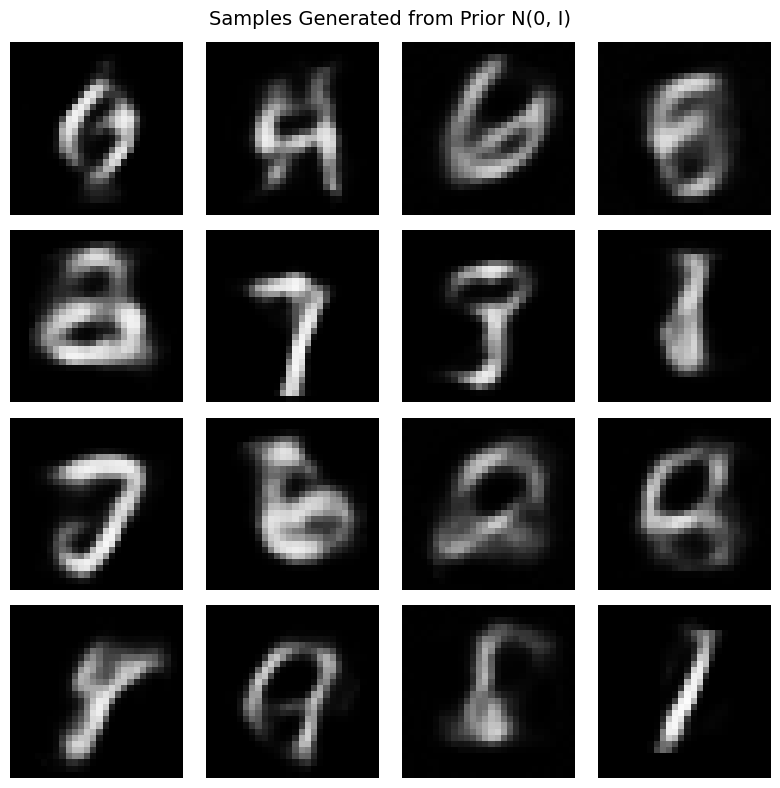

In [21]:
# Generate samples from the higher-dimensional VAE
vae.eval()
num_samples = 16

with torch.no_grad():
    generated = vae.sample(num_samples, device)

# Plot (no denormalization needed)
fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i].cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.axis('off')

plt.suptitle('Samples Generated from Prior N(0, I)', fontsize=14)
plt.tight_layout()
plt.show()

These are **entirely new digits** that don't exist in the training set! The VAE has learned the distribution of handwritten digits.

## Latent Space Interpolation

Another powerful capability: **interpolate** between two images in latent space to see smooth transitions.

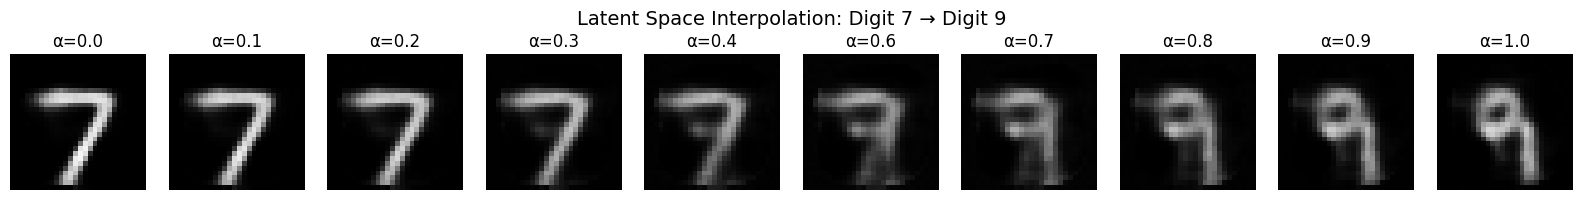

In [22]:
# Select two test images
vae.eval()
idx1, idx2 = 0, 7  # Choose different digits
img1 = test_batch[idx1:idx1+1]
img2 = test_batch[idx2:idx2+1]

# Encode to latent space
with torch.no_grad():
    mu1, _ = vae.encode(img1)
    mu2, _ = vae.encode(img2)
    
    # Linear interpolation
    n_steps = 10
    alphas = np.linspace(0, 1, n_steps)
    interpolated = []
    
    for alpha in alphas:
        z_interp = (1 - alpha) * mu1 + alpha * mu2
        img_interp = vae.decode(z_interp)
        interpolated.append(img_interp)
    
    interpolated = torch.cat(interpolated, dim=0).cpu()

# Plot interpolation (no denormalization needed)
fig, axes = plt.subplots(1, n_steps, figsize=(16, 2))
for i in range(n_steps):
    axes[i].imshow(interpolated[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(f'α={alphas[i]:.1f}')
    axes[i].axis('off')

plt.suptitle(f'Latent Space Interpolation: Digit {test_labels[idx1].item()} → Digit {test_labels[idx2].item()}', 
             fontsize=14)
plt.tight_layout()
plt.show()

Notice the **smooth, semantically meaningful transitions**. This is only possible because VAE regularization ensures the latent space is continuous.

## Latent Space Arithmetic

We can perform **vector arithmetic** in latent space to manipulate semantic attributes.

In [23]:
# Find latent codes for specific digits
def get_digit_latent_mean(digit, vae, dataloader, device, n_samples=100):
    """Compute mean latent code for a specific digit class."""
    latent_codes = []
    count = 0
    
    vae.eval()
    with torch.no_grad():
        for data, labels in dataloader:
            if count >= n_samples:
                break
            
            # Select only the target digit
            mask = labels == digit
            if mask.sum() == 0:
                continue
            
            data = data[mask].to(device)
            mu, _ = vae.encode(data)
            latent_codes.append(mu)
            count += mu.size(0)
    
    latent_codes = torch.cat(latent_codes, dim=0)[:n_samples]
    return latent_codes.mean(dim=0)

# Get mean latent codes for digits 6 and 9
z_6 = get_digit_latent_mean(6, vae, test_loader, device)
z_9 = get_digit_latent_mean(9, vae, test_loader, device)

print("Computing digit prototypes in latent space...")
print(f"z_6 norm: {z_6.norm().item():.4f}")
print(f"z_9 norm: {z_9.norm().item():.4f}")

Computing digit prototypes in latent space...
z_6 norm: 1.8187
z_9 norm: 1.8396


Now let's try latent arithmetic: **can we create an 8 by combining 6 and 9?**

**Intuition:** 
- **6** has a loop at the **bottom**
- **9** has a loop at the **top**
- **8** has **both loops**

If we average their latent codes `(z_6 + z_9) / 2`, we should get something that combines both features!

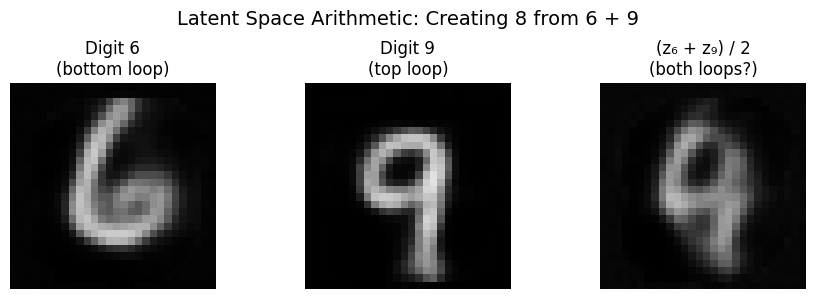

In [24]:
# Latent arithmetic
vae.eval()
with torch.no_grad():
    # Original digits
    img_6 = vae.decode(z_6.unsqueeze(0))
    img_9 = vae.decode(z_9.unsqueeze(0))
    
    # Arithmetic: combine 6 + 9 to create 8
    z_combined = (z_6 + z_9) / 2  # Average to keep magnitude reasonable
    img_combined = vae.decode(z_combined.unsqueeze(0))
    
    # No denormalization needed
    images = torch.cat([img_6, img_9, img_combined], dim=0).cpu()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
titles = ['Digit 6\n(bottom loop)', 'Digit 9\n(top loop)', '(z₆ + z₉) / 2\n(both loops?)']

for i, (ax, title) in enumerate(zip(axes, titles)):
    ax.imshow(images[i].squeeze(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.suptitle('Latent Space Arithmetic: Creating 8 from 6 + 9', fontsize=14)
plt.tight_layout()
plt.show()

The result shows how the VAE has learned a **structured vector space** where semantic features can be combined! 

By averaging the latent codes for 6 (bottom loop) and 9 (top loop), we get a digit that resembles 8 (both loops). This demonstrates that:
- **Individual features** (like "top loop" or "bottom loop") are captured as directions in latent space
- **Combining features** via arithmetic operations produces semantically meaningful results
- The latent space encodes **compositional structure** of the data

## Understanding β in β-VAE

The parameter $\beta$ in the loss function controls the **reconstruction-regularization tradeoff**:

$$\mathcal{L} = \text{Reconstruction} + \beta \cdot D_{\text{KL}}$$

Let's train VAEs with different $\beta$ values and compare.

In [25]:
# Train VAEs with different beta values
beta_values = [0.1, 1.0, 4.0]
beta_models = {}

for beta in beta_values:
    print(f"\nTraining with β={beta}...")
    
    # Create model
    model = VAE(input_dim=784, hidden_dim=400, latent_dim=20).to(device)
    criterion_beta = VAELoss(reconstruction_loss='mse', beta=beta)
    optimizer_beta = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # Train for 5 epochs (quick comparison)
    for epoch in range(5):
        train_loss, train_recon, train_kl = train_epoch(
            model, train_loader, criterion_beta, optimizer_beta, device
        )
        print(f"  Epoch {epoch+1}/5 - Loss: {train_loss:.4f}")
    
    beta_models[beta] = model

print("\nTraining complete for all β values!")


Training with β=0.1...


Training:   0%|          | 0/469 [00:00<?, ?it/s]

  Epoch 1/5 - Loss: 32.7611


Training:   0%|          | 0/469 [00:00<?, ?it/s]

  Epoch 2/5 - Loss: 16.8988


...

  Epoch 3/5 - Loss: 49.4662


Training:   0%|          | 0/469 [00:00<?, ?it/s]

  Epoch 4/5 - Loss: 48.9868


Training:   0%|          | 0/469 [00:00<?, ?it/s]

  Epoch 5/5 - Loss: 48.6274

Training complete for all β values!


Compare reconstructions across different β values.

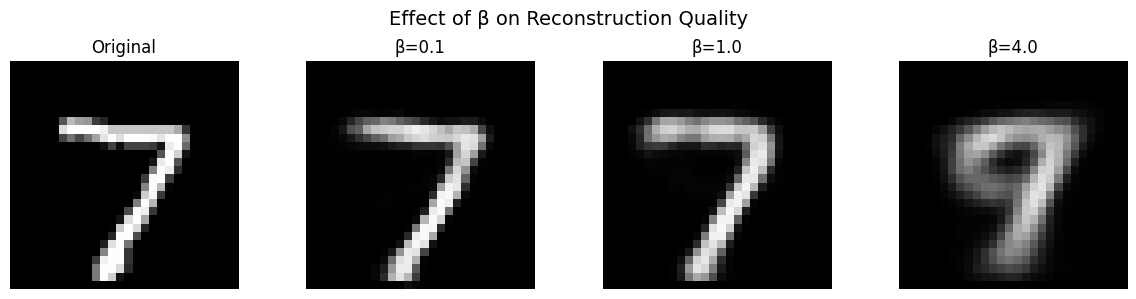

In [26]:
# Compare reconstructions
test_img = test_batch[0:1]

fig, axes = plt.subplots(1, len(beta_values) + 1, figsize=(12, 3))

# Original (no denormalization needed)
axes[0].imshow(test_img.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original')
axes[0].axis('off')

# Reconstructions for each beta
for i, beta in enumerate(beta_values):
    model = beta_models[beta]
    model.eval()
    with torch.no_grad():
        recon, _, _ = model(test_img)
    
    axes[i+1].imshow(recon.cpu().squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[i+1].set_title(f'β={beta}')
    axes[i+1].axis('off')

plt.suptitle('Effect of β on Reconstruction Quality', fontsize=14)
plt.tight_layout()
plt.show()

**Key observations:**
- **β < 1**: Sharper reconstructions (less regularization)
- **β = 1**: Standard VAE balance
- **β > 1**: Blurrier reconstructions but potentially better disentangled latent space

Higher β encourages **disentanglement** (independent latent dimensions) at the cost of reconstruction quality.

## Key Takeaways

### What We Learned

1. **VAEs vs Regular Autoencoders**
   - Regular AEs: arbitrary, scattered latent codes
   - VAEs: structured, probabilistic latent space

2. **The VAE Objective**
   - Reconstruction loss: minimize $||x - \hat{x}||^2$
   - KL divergence: regularize latent space to match prior $\mathcal{N}(0, I)$
   - Balance controlled by $\beta$ parameter

3. **Reparameterization Trick**
   - Makes sampling differentiable: $z = \mu + \sigma \odot \epsilon$
   - Essential for training with backpropagation

4. **Latent Space Properties**
   - Continuous manifold (smooth transitions)
   - Meaningful clusters (semantic structure)
   - Supports generation, interpolation, and arithmetic

5. **Applications**
   - **Generation**: Sample from $p(z)$ to create new data
   - **Interpolation**: Smooth transitions between data points
   - **Latent arithmetic**: Semantic manipulation via vector operations

### Why VAEs Matter

VAEs are foundational to modern generative modeling:
- **Latent diffusion models** (Stable Diffusion) use VAE latent spaces
- **Reinforcement learning** uses VAE-like objectives (state representation)
- **Representation learning** benefits from structured latent spaces

### Next Steps

- **VQ-VAE**: Discrete latent codes for better reconstruction
- **Hierarchical VAEs**: Multi-scale latent representations
- **Conditional VAE**: Control generation with labels
- **Diffusion Models**: State-of-the-art generation via iterative denoising